# CNN ve Transfer Learning ile Sitma Hücre Görüntülerinin Sınıflandırılması


## Proje Görseli

Aşağıdaki görselde veri setinden alınan enfekte ve enfekte olmayan hücre örnekleri gösterilmektedir. Bu görsel, projenin temel amacını yani hücre görüntülerinden sınıflandırma yapmayı temsil eder.


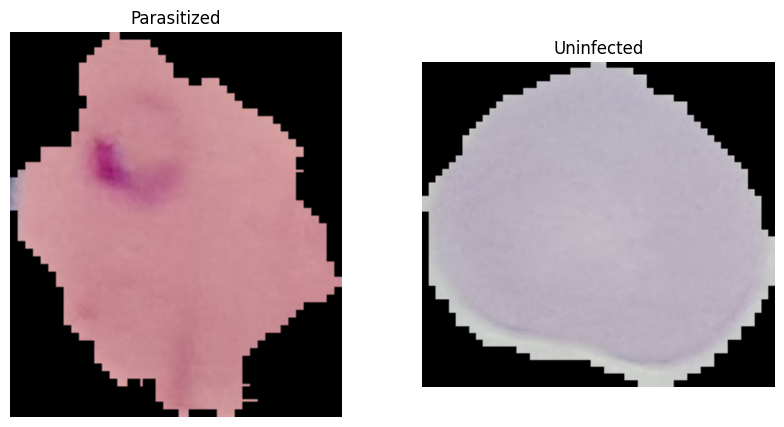

In [28]:
# Proje görselinde gerçek veri setinden örnek hücreleri göstermek için gerekli kütüphaneleri kullanıyoruz
import os
import matplotlib.pyplot as plt
from PIL import Image

# Veri setinin ana klasör yolunu belirliyoruz
data_dir = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images"

# Enfekte hücrelerin bulunduğu klasör yolunu oluşturuyoruz
parasitized_path = data_dir + "/Parasitized"

# Enfekte olmayan hücrelerin bulunduğu klasör yolunu oluşturuyoruz
uninfected_path = data_dir + "/Uninfected"

# Her iki sınıftan birer örnek görsel seçiyoruz
p_img = Image.open(parasitized_path + "/" + os.listdir(parasitized_path)[0])
u_img = Image.open(uninfected_path + "/" + os.listdir(uninfected_path)[0])

# Proje görseli için yan yana iki örnek hücre gösteriyoruz
plt.figure(figsize=(10, 5))

# Enfekte hücre örneğini gösteriyoruz
plt.subplot(1, 2, 1)
plt.imshow(p_img)
plt.title("Parasitized")
plt.axis("off")

# Enfekte olmayan hücre örneğini gösteriyoruz
plt.subplot(1, 2, 2)
plt.imshow(u_img)
plt.title("Uninfected")
plt.axis("off")

# Görseli ekranda gösteriyoruz
plt.show()


## Projenin Amacı

Bu projede amaç, mikroskop altında alınmış sitma hücre görüntülerini kullanarak hücrenin enfekte (Parasitized) veya enfekte değil (Uninfected) olup olmadığını derin öğrenme yöntemleriyle sınıflandırmaktır.

## Hedeflenen Sonuç

Bu çalışma sonunda farklı CNN ve Transfer Learning modelleri oluşturularak başarıları karşılaştırılacaktır. Amaç, en iyi performansı veren modeli belirlemek ve model sonuçlarını accuracy, loss ve sınıflandırma metrikleriyle değerlendirmektir.

## Yol Haritası

1. Veri setinin doğru klasör yolunu belirlemek
2. Görselleri eğitim ve doğrulama verisi olarak ayırmak
3. CNN tabanlı modeller oluşturmak
4. Transfer Learning modelleri oluşturmak
5. Modelleri eğitmek
6. Sonuçları karşılaştırmak
7. En başarılı modeli belirlemek


## Veri Setinin Eğitim ve Doğrulama Olarak Ayrılması

Bu aşamada görseller 224x224 boyutuna getirilerek model eğitimine uygun hale getirilecektir. Veri setinin %80’i eğitim, %20’si doğrulama için ayrılacaktır.

In [5]:
# Train ve validation veri setlerini oluşturuyoruz

import tensorflow as tf

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training",
    seed=42, image_size=img_size, batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation",
    seed=42, image_size=img_size, batch_size=batch_size
)

2026-05-10 09:53:59.330920: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778406839.579642      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778406839.650623      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778406840.234737      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778406840.234803      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778406840.234806      57 computation_placer.cc:177] computation placer alr

Found 27558 files belonging to 2 classes.
Using 22047 files for training.


2026-05-10 09:54:34.913265: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 27558 files belonging to 2 classes.
Using 5511 files for validation.


## Veri Sınıflarının Kontrol Edilmesi

Bu adımda modelin hangi sınıfları öğreneceğini kontrol ediyoruz.  
Veri setinde iki sınıf vardır: `Parasitized` enfekte hücreleri, `Uninfected` ise enfekte olmayan hücreleri temsil eder.

Ayrıca eğitim sırasında verinin daha hızlı okunması için `cache` ve `prefetch` kullanıyoruz.


In [6]:
# Modelin tahmin edeceği sınıf adlarını görmek için class_names değişkenine kaydediyoruz
class_names = train_ds.class_names

# Sınıf isimlerini ekrana yazdırarak veri setinin doğru okunduğunu kontrol ediyoruz
print(class_names)

# TensorFlow'un eğitim sırasında veriyi daha hızlı hazırlaması için AUTOTUNE ayarını kullanıyoruz
AUTOTUNE = tf.data.AUTOTUNE

# Eğitim verisini belleğe alarak ve önceden hazırlayarak model eğitimini hızlandırıyoruz
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Doğrulama verisini de aynı şekilde hızlandırmak için cache ve prefetch uyguluyoruz
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


['Parasitized', 'Uninfected']


## İlk CNN Modelinin Oluşturulması

Bu adımda sıfırdan basit bir CNN modeli oluşturuyoruz.  
CNN modeli, görüntülerdeki kenar, renk ve şekil gibi özellikleri öğrenerek hücrelerin enfekte olup olmadığını tahmin etmeye çalışır.

Bu model bizim başlangıç modelimiz olacaktır. Daha sonra Transfer Learning modeliyle karşılaştırarak hangi yaklaşımın daha başarılı olduğunu değerlendireceğiz.


In [7]:
# Model katmanlarını kolay oluşturmak için Sequential yapısını kullanıyoruz
model = tf.keras.Sequential([
    
    # Piksel değerlerini 0-1 aralığına getirerek modeli daha dengeli eğitiyoruz
    tf.keras.layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    
    # Görüntülerden temel görsel özellikleri öğrenmek için ilk convolution katmanını ekliyoruz
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    
    # Özellik haritasını küçülterek önemli bilgileri öne çıkarıyoruz
    tf.keras.layers.MaxPooling2D(),
    
    # Daha karmaşık özellikleri öğrenmek için ikinci convolution katmanını ekliyoruz
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    
    # Veriyi tekrar küçülterek hesaplamayı azaltıyoruz
    tf.keras.layers.MaxPooling2D(),
    
    # Görüntü özelliklerini sınıflandırma katmanına uygun hale getiriyoruz
    tf.keras.layers.Flatten(),
    
    # Öğrenilen özellikleri kullanarak karar verecek yoğun katmanı ekliyoruz
    tf.keras.layers.Dense(128, activation="relu"),
    
    # İki sınıftan birini tahmin etmek için çıkış katmanını oluşturuyoruz
    tf.keras.layers.Dense(2, activation="softmax")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# Modelin katman yapısını kontrol etmek için özetini görüntülüyoruz
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,650 (91.20 MB)

 Trainable params: 23,907,650 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

## Model 1: Basit CNN Modelinin Derlenmesi

Bu adımda oluşturduğumuz ilk CNN modelini eğitime hazır hale getiriyoruz.  
Model iki sınıflı bir sınıflandırma yaptığı için kayıp fonksiyonu olarak `sparse_categorical_crossentropy` kullanıyoruz.

Başarıyı ölçmek için `accuracy` metriğini takip edeceğiz.


In [9]:
# Modelin ağırlıklarını güncellemek için Adam optimizasyon algoritmasını seçiyoruz
optimizer = "adam"

# Çok sınıflı etiket yapısına uygun kayıp fonksiyonunu belirliyoruz
loss = "sparse_categorical_crossentropy"

# Eğitim sırasında başarı oranını takip etmek için accuracy metriğini seçiyoruz
metrics = ["accuracy"]

# Modeli seçilen ayarlarla eğitime hazır hale getiriyoruz
model.compile(optimizer=optimizer, loss=loss, metrics=metrics)


## Model 1: Basit CNN Modelinin Eğitilmesi

Bu adımda basit CNN modelini eğitim verisiyle eğitiyoruz.  
Modelin doğrulama verisindeki başarısını da takip ederek sadece ezber yapıp yapmadığını anlamaya çalışıyoruz.

İlk model karşılaştırma amacıyla kullanıldığı için eğitimi kısa tutuyoruz.


In [10]:
# Model 1'in eğitim sürecini sonradan incelemek için history değişkenine kaydediyoruz
history_model_1 = model.fit(
    
    # Modeli eğitim verisiyle eğitiyoruz
    train_ds,
    
    # Modelin başarısını görmediği doğrulama verisi üzerinde kontrol ediyoruz
    validation_data=val_ds,
    
    # İlk deneme modeli olduğu için eğitimi kısa tutuyoruz
    epochs=3
)


Epoch 1/3
689/689 ━━━━━━━━━━━━━━━━━━━━ 935s 1s/step - accuracy: 0.6299 - loss: 0.9826 - val_accuracy: 0.9289 - val_loss: 0.2426
Epoch 2/3
689/689 ━━━━━━━━━━━━━━━━━━━━ 917s 1s/step - accuracy: 0.9218 - loss: 0.2269 - val_accuracy: 0.9338 - val_loss: 0.1850
Epoch 3/3
689/689 ━━━━━━━━━━━━━━━━━━━━ 951s 1s/step - accuracy: 0.9477 - loss: 0.1513 - val_accuracy: 0.9327 - val_loss: 0.1988


## Model 1 Sonucunun Değerlendirilmesi

Basit CNN modeli doğrulama verisinde yaklaşık %93 başarıya ulaşmıştır.  
Bu sonuç, modelin hücre görüntülerinden enfekte ve enfekte olmayan sınıfları ayırt edebildiğini göstermektedir.

Ancak modelin parametre sayısı yüksek olduğu için eğitim süresi uzun sürmüştür. Bu nedenle sonraki adımda daha hafif ve daha düzenli bir CNN modeli denenecektir.


In [12]:
## Model 2: Daha Hafif CNN Modelinin Oluşturulması

Bu adımda ilk modele göre daha hafif bir CNN modeli oluşturuyoruz.  
İlk modelde `Flatten` katmanı çok fazla parametre oluşturduğu için eğitim süresi uzamıştır.

Bu modelde `GlobalAveragePooling2D` kullanarak parametre sayısını azaltıyoruz. Böylece daha sade, daha hızlı ve karşılaştırmaya uygun ikinci bir model elde ediyoruz.


SyntaxError: invalid syntax (2213061155.py, line 3)

In [11]:
# Model 1'i daha sonra karşılaştırmak için ayrı bir isimle saklıyoruz
model_1 = model

# Model 1'in son doğrulama başarı değerini kaydediyoruz
model_1_val_accuracy = history_model_1.history["val_accuracy"][-1]

# Model 1'in son doğrulama kayıp değerini kaydediyoruz
model_1_val_loss = history_model_1.history["val_loss"][-1]

# Model 1 sonuçlarını ekrana yazdırıyoruz
print("Model 1 Validation Accuracy:", model_1_val_accuracy)
print("Model 1 Validation Loss:", model_1_val_loss)


Model 1 Validation Accuracy: 0.932680070400238
Model 1 Validation Loss: 0.19884784519672394


## Model 2: Daha Hafif CNN Modelinin Oluşturulması

Bu adımda ilk modele göre daha hafif bir CNN modeli oluşturuyoruz.  
İlk modelde `Flatten` katmanı çok fazla parametre oluşturduğu için eğitim süresi uzamıştır.

Bu modelde `GlobalAveragePooling2D` kullanarak parametre sayısını azaltıyoruz. Böylece daha sade, daha hızlı ve karşılaştırmaya uygun ikinci bir model elde ediyoruz.


In [13]:
# Daha hafif ikinci CNN modelini oluşturuyoruz
model_2 = tf.keras.Sequential([
    
    # Piksel değerlerini 0-1 aralığına indirerek eğitimi dengeliyoruz
    tf.keras.layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    
    # Görüntülerden temel özellikleri öğrenmek için ilk convolution katmanını ekliyoruz
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    
    # Önemli özellikleri koruyarak görüntü boyutunu küçültüyoruz
    tf.keras.layers.MaxPooling2D(),
    
    # Daha belirgin görsel örüntüleri öğrenmek için ikinci convolution katmanını ekliyoruz
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    
    # Hesaplama yükünü azaltmak için tekrar boyut küçültüyoruz
    tf.keras.layers.MaxPooling2D(),
    
    # Flatten yerine daha az parametre üreten GlobalAveragePooling2D kullanıyoruz
    tf.keras.layers.GlobalAveragePooling2D(),
    
    # Modelin ezberleme riskini azaltmak için dropout ekliyoruz
    tf.keras.layers.Dropout(0.3),
    
    # İki sınıftan birini tahmin etmek için çıkış katmanını oluşturuyoruz
    tf.keras.layers.Dense(2, activation="softmax")
])


In [14]:
# Model 2'nin katman yapısını ve parametre sayısını kontrol ediyoruz
model_2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,522 (76.26 KB)

 Trainable params: 19,522 (76.26 KB)

 Non-trainable params: 0 (0.00 B)

## Model 2: Daha Hafif CNN Modelinin Derlenmesi ve Eğitilmesi

Bu adımda ikinci CNN modelini eğitime hazır hale getirip eğitiyoruz.  
Model 2, Model 1'e göre çok daha az parametre içerdiği için daha hızlı çalışması beklenir.

Bu modelin amacı, daha sade bir CNN yapısının başarı açısından yeterli olup olmadığını görmektir.


In [15]:
# Model 2'yi Adam optimizasyon algoritmasıyla eğitime hazırlıyoruz
model_2.compile(
    
    # Ağırlıkları güncellemek için Adam algoritmasını kullanıyoruz
    optimizer="adam",
    
    # Etiketler sayısal olduğu için sparse categorical crossentropy seçiyoruz
    loss="sparse_categorical_crossentropy",
    
    # Model başarısını accuracy metriğiyle takip ediyoruz
    metrics=["accuracy"]
)

# Model 2'nin eğitim sonuçlarını daha sonra incelemek için history değişkenine kaydediyoruz
history_model_2 = model_2.fit(
    
    # Modeli eğitim verisiyle eğitiyoruz
    train_ds,
    
    # Modelin doğrulama verisindeki başarısını kontrol ediyoruz
    validation_data=val_ds,
    
    # Karşılaştırma adil olsun diye Model 1 ile aynı epoch sayısını kullanıyoruz
    epochs=3
)


Epoch 1/3
689/689 ━━━━━━━━━━━━━━━━━━━━ 798s 1s/step - accuracy: 0.5714 - loss: 0.6739 - val_accuracy: 0.6779 - val_loss: 0.6292
Epoch 2/3
689/689 ━━━━━━━━━━━━━━━━━━━━ 768s 1s/step - accuracy: 0.6555 - loss: 0.6370 - val_accuracy: 0.7387 - val_loss: 0.5745
Epoch 3/3
689/689 ━━━━━━━━━━━━━━━━━━━━ 766s 1s/step - accuracy: 0.7881 - loss: 0.5496 - val_accuracy: 0.8933 - val_loss: 0.4221


## Model 2: Daha Hafif CNN Modelinin Derlenmesi ve Eğitilmesi

Bu adımda ikinci CNN modelini eğitime hazır hale getirip eğitiyoruz.  
Model 2, Model 1'e göre çok daha az parametre içerdiği için daha hızlı çalışması beklenir.

Bu modelin amacı, daha sade bir CNN yapısının başarı açısından yeterli olup olmadığını görmektir.


In [16]:
# Model 2'yi Adam optimizasyon algoritmasıyla eğitime hazırlıyoruz
model_2.compile(
    
    # Ağırlıkları güncellemek için Adam algoritmasını kullanıyoruz
    optimizer="adam",
    
    # Etiketler sayısal olduğu için sparse categorical crossentropy seçiyoruz
    loss="sparse_categorical_crossentropy",
    
    # Model başarısını accuracy metriğiyle takip ediyoruz
    metrics=["accuracy"]
)

# Model 2'nin eğitim sonuçlarını daha sonra incelemek için history değişkenine kaydediyoruz
history_model_2 = model_2.fit(
    
    # Modeli eğitim verisiyle eğitiyoruz
    train_ds,
    
    # Modelin doğrulama verisindeki başarısını kontrol ediyoruz
    validation_data=val_ds,
    
    # Karşılaştırma adil olsun diye Model 1 ile aynı epoch sayısını kullanıyoruz
    epochs=3
)


Epoch 1/3
689/689 ━━━━━━━━━━━━━━━━━━━━ 763s 1s/step - accuracy: 0.8776 - loss: 0.4034 - val_accuracy: 0.8969 - val_loss: 0.3686
Epoch 2/3
689/689 ━━━━━━━━━━━━━━━━━━━━ 762s 1s/step - accuracy: 0.8862 - loss: 0.3703 - val_accuracy: 0.8980 - val_loss: 0.3551
Epoch 3/3
689/689 ━━━━━━━━━━━━━━━━━━━━ 761s 1s/step - accuracy: 0.8876 - loss: 0.3653 - val_accuracy: 0.8966 - val_loss: 0.3535


## Model 2 Sonucunun Değerlendirilmesi

Daha hafif CNN modeli doğrulama verisinde yaklaşık %90 başarıya ulaşmıştır.  
Bu model, Model 1'e göre çok daha az parametre içerdiği için daha sade bir yapıya sahiptir.

Ancak doğrulama başarısı Model 1'den düşük kalmıştır. Bu nedenle sadece parametre sayısının azalması yeterli olmamış, başarı açısından daha güçlü bir modele ihtiyaç olduğu görülmüştür.


In [18]:
# Model 2'nin son doğrulama başarı değerini kaydediyoruz
model_2_val_accuracy = history_model_2.history["val_accuracy"][-1]

# Model 2'nin son doğrulama kayıp değerini kaydediyoruz
model_2_val_loss = history_model_2.history["val_loss"][-1]

# Model 2 sonuçlarını ekrana yazdırıyoruz
print("Model 2 Validation Accuracy:", model_2_val_accuracy)
print("Model 2 Validation Loss:", model_2_val_loss)


Model 2 Validation Accuracy: 0.8965705037117004
Model 2 Validation Loss: 0.35353487730026245


## Model 3: Transfer Learning Modelinin Oluşturulması

Bu adımda sıfırdan model eğitmek yerine önceden eğitilmiş `MobileNetV2` modelini kullanıyoruz.  
Bu yönteme Transfer Learning denir.

Transfer Learning sayesinde model, daha önce öğrendiği genel görüntü özelliklerini kullanır. Biz sadece sitma hücrelerini sınıflandırmak için son katmanları eğitiriz.


In [22]:
# MobileNetV2 modelini temel model olarak kullanıyoruz
base_model = tf.keras.applications.MobileNetV2(
    
    # Modelin giriş görüntü boyutunu belirliyoruz
    input_shape=(224, 224, 3),
    
    # Hazır sınıflandırma katmanını almayarak kendi sınıflandırma katmanımızı ekleyeceğiz
    include_top=False,
    
    # ImageNet üzerinde öğrenilmiş ağırlıkları kullanıyoruz
    weights="imagenet"
)

# Önceden öğrenilmiş katmanları sabit tutarak sadece yeni eklenen katmanları eğiteceğiz
base_model.trainable = False

# Transfer Learning için üçüncü modeli oluşturuyoruz
model_3 = tf.keras.Sequential([
    
    # Modelin giriş görüntü boyutunu açıkça belirtiyoruz
    tf.keras.layers.Input(shape=(224, 224, 3)),
    
    # MobileNetV2'nin beklediği özel ön işleme adımını uyguluyoruz
    tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    
    # Hazır eğitilmiş MobileNetV2 modelini özellik çıkarıcı olarak kullanıyoruz
    base_model,
    
    # Öğrenilen özellikleri sınıflandırmaya uygun hale getiriyoruz
    tf.keras.layers.GlobalAveragePooling2D(),
    
    # Ezberleme riskini azaltmak için dropout ekliyoruz
    tf.keras.layers.Dropout(0.3),
    
    # İki sınıftan birini tahmin etmek için çıkış katmanını oluşturuyoruz
    tf.keras.layers.Dense(2, activation="softmax")
])

# Model 3'ün katmanlarını tamamen oluşturmak için örnek bir giriş veriyoruz
model_3(tf.zeros((1, 224, 224, 3)))

# Model 3'ün katman yapısını ve parametre sayılarını kontrol ediyoruz
model_3.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Model 3: Transfer Learning Modelinin Derlenmesi ve Eğitilmesi

Bu adımda MobileNetV2 tabanlı Transfer Learning modelini eğitiyoruz.  
Hazır modelin ana katmanları sabit tutulduğu için sadece son sınıflandırma katmanı eğitilir.

Bu sayede daha az eğitilebilir parametreyle güçlü bir görüntü sınıflandırma modeli elde etmeyi hedefliyoruz.


In [23]:
# Model 3'ü Adam optimizasyon algoritmasıyla eğitime hazırlıyoruz
model_3.compile(
    
    # Ağırlıkları güncellemek için Adam algoritmasını kullanıyoruz
    optimizer="adam",
    
    # Etiketler sayısal olduğu için sparse categorical crossentropy seçiyoruz
    loss="sparse_categorical_crossentropy",
    
    # Model başarısını accuracy metriğiyle takip ediyoruz
    metrics=["accuracy"]
)

# Model 3'ün eğitim sonuçlarını daha sonra incelemek için history değişkenine kaydediyoruz
history_model_3 = model_3.fit(
    
    # Modeli eğitim verisiyle eğitiyoruz
    train_ds,
    
    # Modelin doğrulama verisindeki başarısını kontrol ediyoruz
    validation_data=val_ds,
    
    # Diğer modellerle adil karşılaştırma için aynı epoch sayısını kullanıyoruz
    epochs=3
)


Epoch 1/3
689/689 ━━━━━━━━━━━━━━━━━━━━ 524s 754ms/step - accuracy: 0.8445 - loss: 0.3446 - val_accuracy: 0.9318 - val_loss: 0.1804
Epoch 2/3
689/689 ━━━━━━━━━━━━━━━━━━━━ 519s 753ms/step - accuracy: 0.9256 - loss: 0.1983 - val_accuracy: 0.9314 - val_loss: 0.1764
Epoch 3/3
689/689 ━━━━━━━━━━━━━━━━━━━━ 522s 758ms/step - accuracy: 0.9328 - loss: 0.1878 - val_accuracy: 0.9341 - val_loss: 0.1755


## Model 3 Sonucunun Değerlendirilmesi

Transfer Learning modeli doğrulama verisinde yaklaşık %93 başarıya ulaşmıştır.  
Bu modelde MobileNetV2'nin önceden öğrenilmiş görsel özellikleri kullanılmıştır.

Model 3, düşük eğitilebilir parametre sayısına rağmen yüksek başarı verdiği için diğer modellerle karşılaştırıldığında güçlü bir adaydır.


In [24]:
# Model 3'ün son doğrulama başarı değerini kaydediyoruz
model_3_val_accuracy = history_model_3.history["val_accuracy"][-1]

# Model 3'ün son doğrulama kayıp değerini kaydediyoruz
model_3_val_loss = history_model_3.history["val_loss"][-1]

# Model 3 sonuçlarını ekrana yazdırıyoruz
print("Model 3 Validation Accuracy:", model_3_val_accuracy)
print("Model 3 Validation Loss:", model_3_val_loss)


Model 3 Validation Accuracy: 0.9341317415237427
Model 3 Validation Loss: 0.1754801869392395


## Modellerin Karşılaştırılması

Bu adımda üç farklı modelin doğrulama başarı ve kayıp değerlerini karşılaştırıyoruz.  
Amaç, sadece modeli kurmak değil; hangi modelin proje hedefi için daha uygun olduğunu veriye dayanarak seçmektir.

Daha yüksek accuracy ve daha düşük loss değeri daha başarılı bir model anlamına gelir.


In [25]:
# Model sonuçlarını tablo halinde göstermek için pandas kütüphanesini kullanıyoruz
import pandas as pd

# Üç modelin doğrulama sonuçlarını karşılaştırma tablosunda topluyoruz
results = pd.DataFrame({
    
    # Karşılaştırılan model isimlerini yazıyoruz
    "Model": ["Basit CNN", "Hafif CNN", "Transfer Learning"],
    
    # Modellerin doğrulama başarı değerlerini ekliyoruz
    "Validation Accuracy": [model_1_val_accuracy, model_2_val_accuracy, model_3_val_accuracy],
    
    # Modellerin doğrulama kayıp değerlerini ekliyoruz
    "Validation Loss": [model_1_val_loss, model_2_val_loss, model_3_val_loss]
})

# Başarı değerine göre en iyi modeli en üstte görmek için tabloyu sıralıyoruz
results = results.sort_values(by="Validation Accuracy", ascending=False)

# Karşılaştırma tablosunu görüntülüyoruz
results


,Model,Validation Accuracy,Validation Loss
2,Transfer Learning,0.934132,0.175480
0,Basit CNN,0.932680,0.198848
1,Hafif CNN,0.896571,0.353535


## Model Sonuçlarının Grafikle Gösterilmesi

Bu adımda modellerin doğrulama başarı ve kayıp değerlerini grafik üzerinde karşılaştırıyoruz.  
Grafik kullanmak, modeller arasındaki farkları tabloya göre daha kolay yorumlamamızı sağlar.


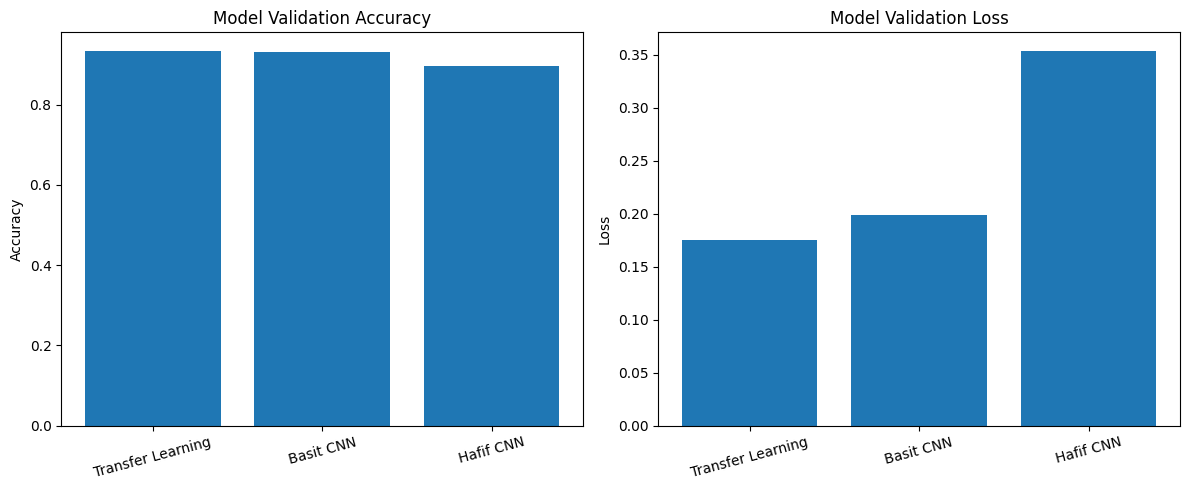

In [26]:
# Karşılaştırma sonuçlarını grafikle göstermek için matplotlib kullanıyoruz
import matplotlib.pyplot as plt

# Grafik alanını belirleyerek iki farklı metriği yan yana göstereceğiz
plt.figure(figsize=(12, 5))

# İlk grafikte modellerin doğrulama başarılarını karşılaştırıyoruz
plt.subplot(1, 2, 1)
plt.bar(results["Model"], results["Validation Accuracy"])
plt.title("Model Validation Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

# İkinci grafikte modellerin doğrulama kayıp değerlerini karşılaştırıyoruz
plt.subplot(1, 2, 2)
plt.bar(results["Model"], results["Validation Loss"])
plt.title("Model Validation Loss")
plt.ylabel("Loss")
plt.xticks(rotation=15)

# Grafiklerin birbirine girmemesi için yerleşimi düzenliyoruz
plt.tight_layout()

# Grafikleri ekranda gösteriyoruz
plt.show()


## Grafik Sonuçlarının Yorumlanması

Grafiklere göre en yüksek doğrulama başarısı Transfer Learning modelinde elde edilmiştir.  
Ayrıca Transfer Learning modeli en düşük doğrulama kayıp değerine sahiptir.

Bu nedenle üç model arasında en dengeli ve başarılı modelin Transfer Learning modeli olduğu görülmektedir.


In [27]:
# En yüksek doğrulama başarısına sahip modeli seçiyoruz
best_model_row = results.iloc[0]

# En iyi modelin adını kaydediyoruz
best_model_name = best_model_row["Model"]

# En iyi modelin doğrulama başarı değerini kaydediyoruz
best_model_accuracy = best_model_row["Validation Accuracy"]

# En iyi modelin doğrulama kayıp değerini kaydediyoruz
best_model_loss = best_model_row["Validation Loss"]

# En iyi modeli ve değerlerini ekrana yazdırıyoruz
print("En iyi model:", best_model_name)
print("Validation Accuracy:", best_model_accuracy)
print("Validation Loss:", best_model_loss)


En iyi model: Transfer Learning
Validation Accuracy: 0.9341317415237427
Validation Loss: 0.1754801869392395


## Sonuç ve Genel Değerlendirme

Bu projeye başlarken hedefimiz, mikroskop altında alınmış hücre görüntülerini kullanarak hücrelerin sitma ile enfekte olup olmadığını sınıflandırmaktı. Bu amaçla `Parasitized` ve `Uninfected` olmak üzere iki sınıflı bir görüntü sınıflandırma problemi üzerinde çalıştık.

Proje sürecinde önce veri setinin doğru klasörlerden okunup okunmadığını kontrol ettik. Daha sonra örnek hücre görüntülerini inceleyerek veri setindeki sınıfların görsel olarak nasıl ayrıldığını gözlemledik. Görüntüleri model eğitimine uygun hale getirmek için eğitim ve doğrulama verisi olarak ayırdık.

Hocamızın istediği şekilde üç farklı model denedik:

- Model 1 olarak basit bir CNN modeli kurduk.
- Model 2 olarak daha hafif ve daha az parametreli bir CNN modeli oluşturduk.
- Model 3 olarak MobileNetV2 tabanlı Transfer Learning modeli kullandık.

Model karşılaştırma sonuçlarına göre en yüksek doğrulama başarısı Transfer Learning modelinde elde edilmiştir. Bu model yaklaşık %93 doğrulama başarısına ulaşmış ve aynı zamanda en düşük doğrulama kayıp değerini vermiştir.

Başlangıçtaki hedefimize göre proje başarılı bir noktaya ulaşmıştır. Çünkü model, hücre görüntülerinden enfekte ve enfekte olmayan sınıfları yüksek doğrulukla ayırt edebilmiştir. Ancak bu sonuçlar bir eğitim projesi kapsamında değerlendirilmelidir. Gerçek tıbbi kullanımlar için daha fazla veri, uzman kontrolü ve klinik doğrulama gerekir.

Bu proje geliştirilecek olursa daha fazla epoch ile eğitim yapılabilir, veri artırma yöntemleri eklenebilir ve farklı Transfer Learning modelleri denenerek başarı daha da artırılabilir.


## En İyi Modelin Seçilmesi

Karşılaştırma tablosu ve grafikler incelendiğinde en başarılı modelin Transfer Learning modeli olduğu görülmüştür.  
Bu model hem en yüksek doğrulama başarısına hem de en düşük doğrulama kayıp değerine sahiptir.

Bu nedenle proje hedefi için en uygun model olarak Transfer Learning modeli seçilmiştir.


## Kapanış

Bu proje sonunda sitma hücre görüntülerinin derin öğrenme yöntemleriyle sınıflandırılabileceği görülmüştür. Üç farklı model denenmiş, sonuçlar tablo ve grafiklerle karşılaştırılmıştır.

Elde edilen sonuçlara göre Transfer Learning modeli en başarılı model olmuştur. Bu model, yaklaşık %93 doğrulama başarısı ve en düşük doğrulama kayıp değeriyle proje hedefi için en uygun model olarak seçilmiştir.

Böylece başlangıçta belirlenen hedefe ulaşılmış, hücre görüntülerinden enfekte ve enfekte olmayan sınıfları ayırt edebilen başarılı bir model geliştirilmiştir.
